# Linear regression

## Libraries and settings

In [67]:
# Libraries
import os
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Show current working directory
print(os.getcwd())

/workspaces/data_analytics/Week_08


## Import the apartment data

In [68]:
# Define columns for import
columns = [ 'web-scraper-order',
            'address_raw',
            'rooms',
            'area',
            'luxurious',
            'price',
            'price_per_m2',
            'lat',
            'lon',
            'bfs_number',
            'bfs_name',
            'pop',
            'pop_dens',
            'frg_pct',
            'emp',
            'mean_taxable_income',
            'dist_supermarket']

# Read and select variables
df_orig = pd.read_csv("apartments_data_enriched_cleaned.csv", 
                      sep=";", 
                      encoding='utf-8')[columns]

# Rename variable 'web-scraper-order' to 'apmt_id'
df_orig = df_orig.rename(columns={'web-scraper-order': 'id'})

# Remove missing values
df = df_orig.dropna()
df.head(5)

# Remove duplicates
df = df.drop_duplicates()

# Remove some 'extreme' values
df = df.loc[(df['price'] >= 1000) & 
            (df['price'] <= 5000)]

print(df.shape)
df.head(5)

(722, 17)


,id,address_raw,rooms,area,luxurious,price,price_per_m2,lat,lon,bfs_number,bfs_name,pop,pop_dens,frg_pct,emp,mean_taxable_income,dist_supermarket
0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",3.0,49,0,1441,29.41,47.252171,8.845797,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,645.652248
1,1693998233-172,"Widacherstrasse 5, 8630 Rüti ZH, ZH",3.0,111,0,2600,23.42,47.252087,8.854919,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,265.102153
2,1693998256-331,"Widenweg 14, 8630 Rüti ZH, ZH",3.0,58,0,1490,25.69,47.253670,8.853993,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,94.401821
3,1693998265-381,"Rain 1, 8630 Rüti ZH, ZH",4.0,118,0,3240,27.46,47.259834,8.851705,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,106.660970
4,1693998276-419,"Bachtelstrasse 24b, 8630 Rüti ZH, ZH",3.0,66,0,1450,21.97,47.266113,8.866872,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,974.844209


## Simple linear regression (only one explanatory variable in the model)
For details see: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html

### Create train and test samples (train = 80%, test = 20% of the data)

In [69]:
# Create train and test samples
X_train, X_test, y_train, y_test = train_test_split(df['area'], 
                                                    df['price'], 
                                                    test_size=0.20, 
                                                    random_state=42)
# Show X_train
print('X_train:')
print(X_train.head(), '\n')

# Show y_train
print('y_train:')
print(y_train.head())

X_train:
503    120
6       65
400     90
644     63
484     91
Name: area, dtype: int64 

y_train:
503    1900
6      1850
400    2090
644    2102
484    1800
Name: price, dtype: int64


### Fit the simple linear regression model

In [70]:
# Fit the regression model
slope, intercept, r, p, std_err = stats.linregress(X_train, y_train)

# Print results of the regression model
print('Linear regression result:')
print(f'Intercept with y-axis (alpha):            {intercept:.2f}')
print(f'Slope of regression line (beta):          {slope:.3f}')
print(f'p-value:                                  {p:.4f}')
print(f'R-squared (coefficient of determination): {r**2:.4f}')

Linear regression result:
Intercept with y-axis (alpha):            1272.94
Slope of regression line (beta):          13.548
p-value:                                  0.0000
R-squared (coefficient of determination): 0.3678


### Plot regression line

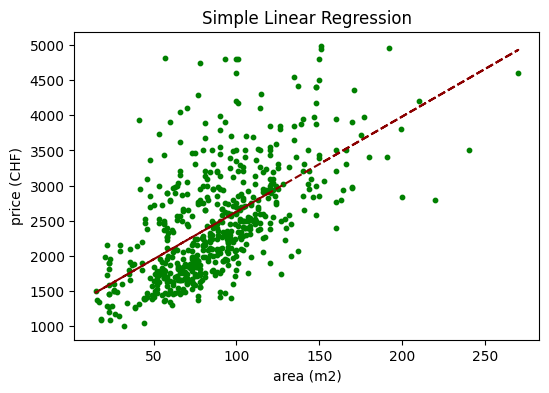

In [71]:
# Function to calculate model predictions
def myfunc(x):
    return slope * x + intercept

# Apply myfunc() to x, i.e. make predictions 
mymodel = pd.Series(map(myfunc, X_train))

# Scatterplot with regression line
plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, s=10, color='green')
plt.plot(X_train, mymodel, color='darkred', linestyle='dashed')
plt.title('Simple Linear Regression')
plt.xlabel('area (m2)')
plt.ylabel('price (CHF)')

plt.show()

### Check model residuals (residuals = observed prices minus predicted prices)

In [72]:
# Calculate model residuals for train data
residuals = y_train - mymodel

# Check the first residual value in our data set
print(f'1st Predicted price in dataset: {mymodel[0]:.2f}')
print(f'1st Observed price in dataset: {y_train[0]:.2f}')
print(f'1st Residual price in dataset: {residuals[0]:.2f}')

1st Predicted price in dataset: 2898.72
1st Observed price in dataset: 1441.00
1st Residual price in dataset: -1457.72

1st Observed price in dataset: 1441.00
1st Residual price in dataset: -1457.72


### Plot histogram of residuals

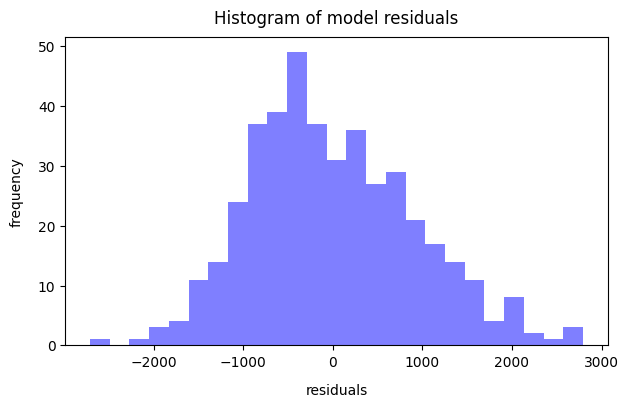

In [73]:
# Plot histogram of residuals
fig = plt.figure( figsize=(7,4))
n, bins, patches = plt.hist(x=residuals, 
                            bins=25, 
                            color='blue',
                            alpha=0.5
                   )

# Set title and labels
plt.xlabel('residuals', fontsize=10, labelpad=10)
plt.ylabel('frequency', fontsize=10, labelpad=10)
plt.title('Histogram of model residuals', fontsize=12, pad=10)

# Show plot
plt.show()

### Compare the observed prices with the predicted prices

In [74]:
# Create model predictions for test data
predicted = myfunc(X_test)
predicted.round(1)

# Compare the observed prices with the predicted prices
for i in range(0,10):
    print(f'Observed price: {y_test.iloc[i]:.1f}, Predicted price: {predicted.iloc[i]:.1f}')

Observed price: 1360.0, Predicted price: 2031.6
Observed price: 1640.0, Predicted price: 2004.5
Observed price: 1568.0, Predicted price: 2167.1
Observed price: 2290.0, Predicted price: 2207.8
Observed price: 4950.0, Predicted price: 2627.8
Observed price: 1787.0, Predicted price: 2248.4
Observed price: 3495.0, Predicted price: 2519.4
Observed price: 2450.0, Predicted price: 2031.6
Observed price: 3390.0, Predicted price: 2871.6
Observed price: 2836.0, Predicted price: 2573.6


## Simple linear regression - Alternative Model (price_per_m2 vs area)

In [75]:
# Create train and test samples with price_per_m2 as target variable
X_train_alt, X_test_alt, y_train_alt, y_test_alt = train_test_split(df['area'], 
                                                                      df['price_per_m2'], 
                                                                      test_size=0.20, 
                                                                      random_state=42)
# Show X_train
print('X_train (alternative model):')
print(X_train_alt.head(), '\n')

# Show y_train
print('y_train (alternative model - price_per_m2):')
print(y_train_alt.head())

X_train (alternative model):
503    120
6       65
400     90
644     63
484     91
Name: area, dtype: int64 

y_train (alternative model - price_per_m2):
503    15.83
6      28.46
400    23.22
644    33.37
484    19.78
Name: price_per_m2, dtype: float64


### Fit the simple linear regression model (price_per_m2)

In [76]:
# Fit the regression model with price_per_m2 as target variable
slope_alt, intercept_alt, r_alt, p_alt, std_err_alt = stats.linregress(X_train_alt, y_train_alt)

# Print results of the regression model
print('Linear regression result (Alternative Model - price_per_m2 vs area):')
print(f'Intercept with y-axis (alpha):            {intercept_alt:.2f}')
print(f'Slope of regression line (beta):          {slope_alt:.6f}')
print(f'p-value:                                  {p_alt:.4f}')
print(f'R-squared (coefficient of determination): {r_alt**2:.4f}')
print('\n')

# Compare R-squared values
print('Comparison of R-squared values:')
print(f'Original model (price vs area):          {r**2:.4f}')
print(f'Alternative model (price_per_m2 vs area): {r_alt**2:.4f}')
if r_alt**2 > r**2:
    print(f'The alternative model has a HIGHER R-squared value (difference: {r_alt**2 - r**2:.4f})')
else:
    print(f'The alternative model has a LOWER R-squared value (difference: {r_alt**2 - r**2:.4f})')

Linear regression result (Alternative Model - price_per_m2 vs area):
Intercept with y-axis (alpha):            51.24
Slope of regression line (beta):          -0.226531
p-value:                                  0.0000
R-squared (coefficient of determination): 0.3551


Comparison of R-squared values:
Original model (price vs area):          0.3678
Alternative model (price_per_m2 vs area): 0.3551
The alternative model has a LOWER R-squared value (difference: -0.0127)


### Check model residuals (price_per_m2)

In [77]:
# Function to calculate model predictions for alternative model
def myfunc_alt(x):
    return slope_alt * x + intercept_alt

# Apply myfunc_alt() to x, i.e. make predictions 
mymodel_alt = pd.Series(map(myfunc_alt, X_train_alt)).values

# Calculate model residuals for train data
residuals_alt = y_train_alt.values - mymodel_alt

# Check the first residual value in our data set
print(f'1st Predicted price_per_m2 in dataset: {mymodel_alt[0]:.2f}')
print(f'1st Observed price_per_m2 in dataset: {y_train_alt.iloc[0]:.2f}')
print(f'1st Residual price_per_m2 in dataset: {residuals_alt[0]:.2f}')

1st Predicted price_per_m2 in dataset: 24.05
1st Observed price_per_m2 in dataset: 15.83
1st Residual price_per_m2 in dataset: -8.22


### Plot histogram of residuals (price_per_m2)

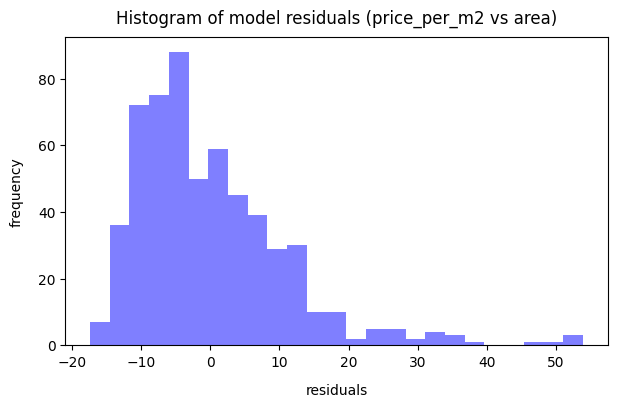

Assessment of residuals normality:
Mean of residuals: 0.000000
Standard deviation of residuals: 10.935223
Skewness: 1.5635
Kurtosis: 3.7869

Shapiro-Wilk normality test:
Test statistic: 0.8884
p-value: 0.000000
Result: Residuals are NOT NORMALLY DISTRIBUTED (p <= 0.05)


In [78]:
# Plot histogram of residuals
fig = plt.figure(figsize=(7,4))
n, bins, patches = plt.hist(x=residuals_alt, 
                            bins=25, 
                            color='blue',
                            alpha=0.5
                   )

# Set title and labels
plt.xlabel('residuals', fontsize=10, labelpad=10)
plt.ylabel('frequency', fontsize=10, labelpad=10)
plt.title('Histogram of model residuals (price_per_m2 vs area)', fontsize=12, pad=10)

# Show plot
plt.show()

# Assess normality of residuals
print('Assessment of residuals normality:')
print(f'Mean of residuals: {residuals_alt.mean():.6f}')
print(f'Standard deviation of residuals: {residuals_alt.std():.6f}')
print(f'Skewness: {stats.skew(residuals_alt):.4f}')
print(f'Kurtosis: {stats.kurtosis(residuals_alt):.4f}')

# Perform normality test (Shapiro-Wilk test)
shapiro_stat, shapiro_p = stats.shapiro(residuals_alt)
print(f'\nShapiro-Wilk normality test:')
print(f'Test statistic: {shapiro_stat:.4f}')
print(f'p-value: {shapiro_p:.6f}')

if shapiro_p > 0.05:
    print('Result: Residuals are NORMALLY DISTRIBUTED (p > 0.05)')
else:
    print('Result: Residuals are NOT NORMALLY DISTRIBUTED (p <= 0.05)')

## Simple linear regression - Alternative Model 2 (price_per_m2 vs rooms)

In [79]:
# Create train and test samples with price_per_m2 as target variable and rooms as explanatory variable
X_train_alt2, X_test_alt2, y_train_alt2, y_test_alt2 = train_test_split(df['rooms'], 
                                                                          df['price_per_m2'], 
                                                                          test_size=0.20, 
                                                                          random_state=42)
# Show X_train
print('X_train (alternative model 2 - rooms):')
print(X_train_alt2.head(), '\n')

# Show y_train
print('y_train (alternative model 2 - price_per_m2):')
print(y_train_alt2.head())

X_train (alternative model 2 - rooms):
503    6.5
6      3.5
400    3.5
644    2.5
484    3.5
Name: rooms, dtype: float64 

y_train (alternative model 2 - price_per_m2):
503    15.83
6      28.46
400    23.22
644    33.37
484    19.78
Name: price_per_m2, dtype: float64


### Fit the simple linear regression model (price_per_m2 vs rooms)

In [80]:
# Fit the regression model with price_per_m2 as target variable and rooms as explanatory variable
slope_alt2, intercept_alt2, r_alt2, p_alt2, std_err_alt2 = stats.linregress(X_train_alt2, y_train_alt2)

# Print results of the regression model
print('Linear regression result (Alternative Model 2 - price_per_m2 vs rooms):')
print(f'Intercept with y-axis (alpha):            {intercept_alt2:.2f}')
print(f'Slope of regression line (beta):          {slope_alt2:.6f}')
print(f'p-value:                                  {p_alt2:.4f}')
print(f'R-squared (coefficient of determination): {r_alt2**2:.4f}')
print('\n')

# Compare R-squared values
print('Comparison of R-squared values:')
print(f'Original model (price vs area):              {r**2:.4f}')
print(f'Alternative model 1 (price_per_m2 vs area): {r_alt**2:.4f}')
print(f'Alternative model 2 (price_per_m2 vs rooms):{r_alt2**2:.4f}')
if r_alt2**2 > r**2:
    print(f'Alternative model 2 has a HIGHER R-squared value than original model (difference: {r_alt2**2 - r**2:.4f})')
else:
    print(f'Alternative model 2 has a LOWER R-squared value than original model (difference: {r_alt2**2 - r**2:.4f})')

Linear regression result (Alternative Model 2 - price_per_m2 vs rooms):
Intercept with y-axis (alpha):            52.96
Slope of regression line (beta):          -6.281677
p-value:                                  0.0000
R-squared (coefficient of determination): 0.3116


Comparison of R-squared values:
Original model (price vs area):              0.3678
Alternative model 1 (price_per_m2 vs area): 0.3551
Alternative model 2 (price_per_m2 vs rooms):0.3116
Alternative model 2 has a LOWER R-squared value than original model (difference: -0.0562)


### Check model residuals (price_per_m2 vs rooms)

In [81]:
# Function to calculate model predictions for alternative model 2
def myfunc_alt2(x):
    return slope_alt2 * x + intercept_alt2

# Apply myfunc_alt2() to x, i.e. make predictions 
mymodel_alt2 = pd.Series(map(myfunc_alt2, X_train_alt2)).values

# Calculate model residuals for train data
residuals_alt2 = y_train_alt2.values - mymodel_alt2

# Check the first residual value in our data set
print(f'1st Predicted price_per_m2 in dataset: {mymodel_alt2[0]:.2f}')
print(f'1st Observed price_per_m2 in dataset: {y_train_alt2.iloc[0]:.2f}')
print(f'1st Residual price_per_m2 in dataset: {residuals_alt2[0]:.2f}')

1st Predicted price_per_m2 in dataset: 12.13
1st Observed price_per_m2 in dataset: 15.83
1st Residual price_per_m2 in dataset: 3.70


### Plot histogram of residuals (price_per_m2 vs rooms)

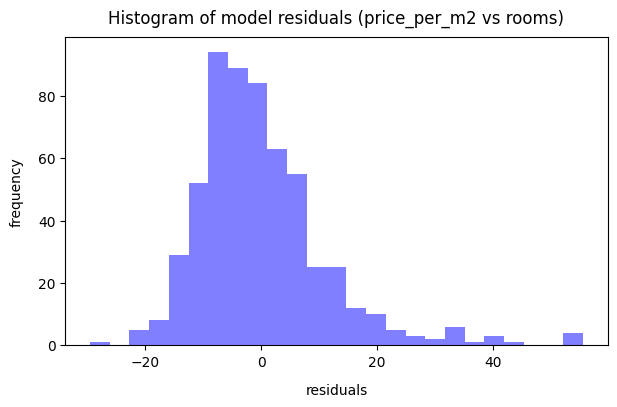

Assessment of residuals normality:
Mean of residuals: -0.000000
Standard deviation of residuals: 11.297938
Skewness: 1.5414
Kurtosis: 4.2545

Shapiro-Wilk normality test:
Test statistic: 0.8995
p-value: 0.000000
Result: Residuals are NOT NORMALLY DISTRIBUTED (p <= 0.05)


In [82]:
# Plot histogram of residuals
fig = plt.figure(figsize=(7,4))
n, bins, patches = plt.hist(x=residuals_alt2, 
                            bins=25, 
                            color='blue',
                            alpha=0.5
                   )

# Set title and labels
plt.xlabel('residuals', fontsize=10, labelpad=10)
plt.ylabel('frequency', fontsize=10, labelpad=10)
plt.title('Histogram of model residuals (price_per_m2 vs rooms)', fontsize=12, pad=10)

# Show plot
plt.show()

# Assess normality of residuals
print('Assessment of residuals normality:')
print(f'Mean of residuals: {residuals_alt2.mean():.6f}')
print(f'Standard deviation of residuals: {residuals_alt2.std():.6f}')
print(f'Skewness: {stats.skew(residuals_alt2):.4f}')
print(f'Kurtosis: {stats.kurtosis(residuals_alt2):.4f}')

# Perform normality test (Shapiro-Wilk test)
shapiro_stat2, shapiro_p2 = stats.shapiro(residuals_alt2)
print(f'\nShapiro-Wilk normality test:')
print(f'Test statistic: {shapiro_stat2:.4f}')
print(f'p-value: {shapiro_p2:.6f}')

if shapiro_p2 > 0.05:
    print('Result: Residuals are NORMALLY DISTRIBUTED (p > 0.05)')
else:
    print('Result: Residuals are NOT NORMALLY DISTRIBUTED (p <= 0.05)')

## Multiple linear regression (more than one explanatory variable in the model)
For details see: https://www.statsmodels.org/dev/examples/notebooks/generated/predict.html

### Create train and test samples (train = 80%, test = 20% of the data)

In [83]:
# Create train and test samples with area, pop_dens, mean_taxable_income, and dist_supermarket
X2_train, X2_test, y2_train, y2_test = train_test_split(df[['area',
                                                            'pop_dens',
                                                            'mean_taxable_income',
                                                            'dist_supermarket']], 
                                                        df['price'], 
                                                        test_size=0.20, 
                                                        random_state=42)

# Show X2_train
print('X2_train:')
print(X2_train.head(), '\n')

# Show y2_train
print('y2_train:')
print(y2_train.head())

X2_train:
     area     pop_dens  mean_taxable_income  dist_supermarket
503   120   165.018625          65380.98802       1958.318650
6      65   525.662252         111422.35870        282.095910
400    90   424.146342          72133.75058       2606.231069
644    63  1044.628957          70964.08794        564.607066
484    91   399.525129          62000.54187        646.823905 

y2_train:
503    1900
6      1850
400    2090
644    2102
484    1800
Name: price, dtype: int64


### Fit the multiple regression model (yes, the output is rich :-), but we need only part of it for interpretation!)

In [84]:
# Add constant to the model
X2_train_const = sm.add_constant(X2_train)

# Create the multiple regression model
olsmod = sm.OLS(y_train, X2_train_const)
olsres = olsmod.fit()

# Print full model output
print(olsres.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.611
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                     225.0
Date:                Sun, 30 Nov 2025   Prob (F-statistic):          6.98e-116
Time:                        13:33:38   Log-Likelihood:                -4403.2
No. Observations:                 577   AIC:                             8816.
Df Residuals:                     572   BIC:                             8838.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                -386.2135    

In [85]:
# Extract and display statistical significance of variables
print('\n' + '='*80)
print('STATISTICAL SIGNIFICANCE ANALYSIS (5% significance level)')
print('='*80)
print('\nVariable                   | P-value  | Significant? (P < 0.05)')
print('-'*80)

# Get the summary as a dictionary for easier access
summary_dict = olsres.summary2().tables[1]

variables = ['area', 'pop_dens', 'mean_taxable_income', 'dist_supermarket']

for var in variables:
    p_value = summary_dict.loc[var, 'P>|t|']
    is_significant = 'YES' if p_value < 0.05 else 'NO'
    print(f'{var:26} | {p_value:8.6f} | {is_significant}')

print('='*80)
print('\nSUMMARY:')
print('-'*80)
for var in variables:
    p_value = summary_dict.loc[var, 'P>|t|']
    if p_value < 0.05:
        print(f'✓ {var:30} is STATISTICALLY SIGNIFICANT (p = {p_value:.6f})')
    else:
        print(f'✗ {var:30} is NOT statistically significant (p = {p_value:.6f})')
print('='*80)


STATISTICAL SIGNIFICANCE ANALYSIS (5% significance level)

Variable                   | P-value  | Significant? (P < 0.05)
--------------------------------------------------------------------------------
area                       | 0.000000 | YES
pop_dens                   | 0.000000 | YES
mean_taxable_income        | 0.000000 | YES
dist_supermarket           | 0.513728 | NO

SUMMARY:
--------------------------------------------------------------------------------
✓ area                           is STATISTICALLY SIGNIFICANT (p = 0.000000)
✓ pop_dens                       is STATISTICALLY SIGNIFICANT (p = 0.000000)
✓ mean_taxable_income            is STATISTICALLY SIGNIFICANT (p = 0.000000)
✗ dist_supermarket               is NOT statistically significant (p = 0.513728)


### Interpretation of the relevant (in this course) statistics in the table above

<b>R-squared:</b> This is the coefficient of determination (see slides of lessons). A value of 0.611 means, that the explanatory variables explain 61.1% of the variation of our target variable (rental prices) - an improvement from the previous model.

<b>coef:</b> These are the estimated coefficients of the explanatory variables ('slopes of the regression line' of each variable). These are needed for the price predictions in our model.

<b>P>|t|:</b> These are the p-values. If < 0.05, the explanatory variables show a statistically significant (5% significance level) contribution in explaining the target variable. In this model:
- <b>area</b>: P>|t| = 0.000 → STATISTICALLY SIGNIFICANT
- <b>pop_dens</b>: P>|t| = 0.000 → STATISTICALLY SIGNIFICANT
- <b>mean_taxable_income</b>: P>|t| = 0.000 → STATISTICALLY SIGNIFICANT
- <b>dist_supermarket</b>: P>|t| = 0.514 → NOT statistically significant (p > 0.05)

### Plot histogram of residuals

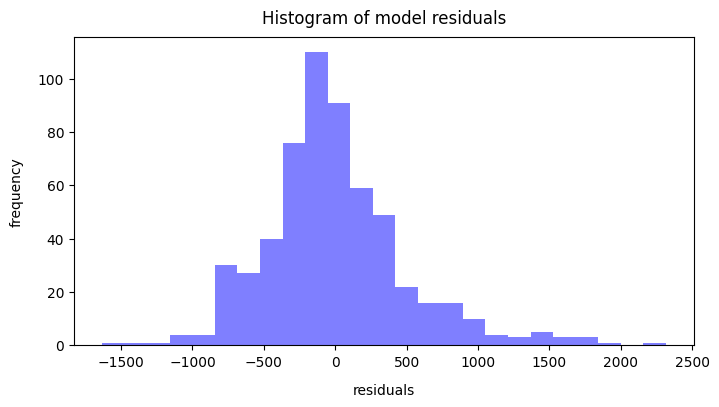

In [86]:
# Plot histogram of residuals
fig = plt.figure( figsize=(8,4))
n, bins, patches = plt.hist(x=olsres.resid, 
                            bins=25, 
                            color='blue',
                            alpha=0.5
                   )

# Set labels
plt.xlabel('residuals', fontsize=10, labelpad=10)
plt.ylabel('frequency', fontsize=10, labelpad=10)
plt.title('Histogram of model residuals', fontsize=12, pad=10)

plt.show()

### Compare the observed prices with the predicted prices

In [87]:
# Add constant to X2_test
X2_test_const = sm.add_constant(X2_test)
predicted_new = olsres.predict(X2_test_const)

# Compare the observed prices with the predicted prices
for i in range(0,10):
    print(f'Observed price: {y_test.iloc[i]:.1f}, Predicted price: {predicted_new.iloc[i]:.1f}')

Observed price: 1360.0, Predicted price: 1660.8
Observed price: 1640.0, Predicted price: 1542.6
Observed price: 1568.0, Predicted price: 1808.3
Observed price: 2290.0, Predicted price: 2720.3
Observed price: 4950.0, Predicted price: 3321.1
Observed price: 1787.0, Predicted price: 2272.2
Observed price: 3495.0, Predicted price: 3121.7
Observed price: 2450.0, Predicted price: 2491.4
Observed price: 3390.0, Predicted price: 2736.0
Observed price: 2836.0, Predicted price: 2312.0


### Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [88]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1030-azure
Datetime: 2025-11-30 13:33:39
Python Version: 3.11.13
-----------------------------------
